In [2]:
from google.colab import files


uploaded = files.upload()

Saving step-2-table.csv to step-2-table.csv


In [5]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.ticker as ticker
import seaborn as sns

df = pd.read_csv('step-2-table.csv')
print("Shape:", df.shape)
print("Columns:", list(df.columns))
print()

Shape: (678240, 21)
Columns: ['[run number]', 'vaccination-rate-A', 'vaccination-rate-B', 'removal-rate', 'claim-rate', 'number-people', 'duration', 'bite-rate', 'infectiousness', 'chance-recover', '[step]', 'total-infected-ever', 'peak-sick', 'count turtles', 'infected-A', 'infected-B', 'population-A', 'population-B', 'total-removed', 'total-claimed', 'total-died']



In [6]:
# Identify parameter columns — adjust names if yours differ
VAX_A    = 'vaccination-rate-A'
VAX_B    = 'vaccination-rate-B'
REMOVAL  = 'removal-rate'
STEP     = '[step]'
RUN      = '[run number]'

print("Parameter ranges:")
for col in [VAX_A, VAX_B, REMOVAL]:
    print(f"  {col}: {sorted(df[col].unique())}")
print(f"  Ticks: 0 to {df[STEP].max()}")
print(f"  Total runs: {df[RUN].nunique()}")
print()


Parameter ranges:
  vaccination-rate-A: [np.int64(0), np.int64(20), np.int64(60), np.int64(90)]
  vaccination-rate-B: [np.int64(0), np.int64(20), np.int64(60), np.int64(90)]
  removal-rate: [np.int64(0), np.int64(30), np.int64(80)]
  Ticks: 0 to 156
  Total runs: 4320



In [7]:
# CREATE LABELS (on final tick only)
final = df[df[STEP] == df[STEP].max()].copy().reset_index(drop=True)

final['outbreak_A'] = (final['infected-A'] > 0).astype(int)
final['outbreak_B'] = (final['infected-B'] > 0).astype(int)
final['outbreak_both'] = ((final['infected-A'] > 0) | (final['infected-B'] > 0)).astype(int)
final['approx_total'] = final['count turtles'] + final['total-infected-ever']
final['infection_rate'] = (final['total-infected-ever'] / final['approx_total']).round(3)
final['removal_triggered'] = (final['total-removed'] > 0).astype(int)

print("=== FINAL TICK SUMMARY ===")
print(f"Runs where A still has infection: {final['outbreak_A'].mean()*100:.1f}%")
print(f"Runs where B still has infection: {final['outbreak_B'].mean()*100:.1f}%")
print(f"Removal triggered: {final['removal_triggered'].mean()*100:.1f}%")
print()

=== FINAL TICK SUMMARY ===
Runs where A still has infection: 6.8%
Runs where B still has infection: 7.4%
Removal triggered: 31.9%



In [10]:
# ANALYSIS 1 — Does A's removal protect B?

print("=== INFECTED-B by removal rate (averaged across all vax levels) ===")
print(df[df[STEP] == df[STEP].max()].groupby(REMOVAL)[
    ['infected-A','infected-B','population-A','population-B']
].mean().round(2))
print()

print("=== INFECTED-B by vaccination-A and removal-rate ===")
pivot_B = final.groupby([VAX_A, REMOVAL])['infected-B'].mean().unstack().round(2)
print(pivot_B)
print()

# ANALYSIS 2 — Spillover: does B infect A?
print("=== INFECTED-A by vaccination-B and removal-rate ===")
pivot_A = final.groupby([VAX_B, REMOVAL])['infected-A'].mean().unstack().round(2)
print(pivot_A)
print()

# ════════════════════════════════════════════════════════
# ANALYSIS 3 — Total died (ethical cost)
# ════════════════════════════════════════════════════════
print("=== TOTAL DIED by vaccination-A and removal-rate ===")
pivot_died = final.groupby([VAX_A, REMOVAL])['total-died'].mean().unstack().round(1)
print(pivot_died)
print()

# ════════════════════════════════════════════════════════
# ANALYSIS 4 — Population dynamics
# ════════════════════════════════════════════════════════
print("=== FINAL POPULATION-A by vaccination-A and removal-rate ===")
pivot_popA = final.groupby([VAX_A, REMOVAL])['population-A'].mean().unstack().round(1)
print(pivot_popA)
print()

print("=== FINAL POPULATION-B by vaccination-B ===")
print(final.groupby(VAX_B)[['population-B','infected-B']].mean().round(1))
print()


=== INFECTED-B by removal rate (averaged across all vax levels) ===
              infected-A  infected-B  population-A  population-B
removal-rate                                                    
0                   0.49        0.46         95.80         94.95
30                  0.34        0.48         97.10         96.53
80                  0.20        0.33         92.65         96.62

=== INFECTED-B by vaccination-A and removal-rate ===
removal-rate          0     30    80
vaccination-rate-A                  
0                   0.15  0.29  0.16
20                  0.26  0.43  0.26
60                  0.96  0.58  0.50
90                  0.46  0.64  0.42

=== INFECTED-A by vaccination-B and removal-rate ===
removal-rate          0     30    80
vaccination-rate-B                  
0                   0.17  0.16  0.15
20                  0.41  0.25  0.28
60                  0.93  0.61  0.26
90                  0.47  0.33  0.11

=== TOTAL DIED by vaccination-A and removal-rate ===
r

In [11]:
C_A    = '#2E86AB'   # blue — Community A
C_B    = '#E84855'   # red — Community B
C_BG   = '#F8F9FA'
C_DARK = '#1A1A2E'

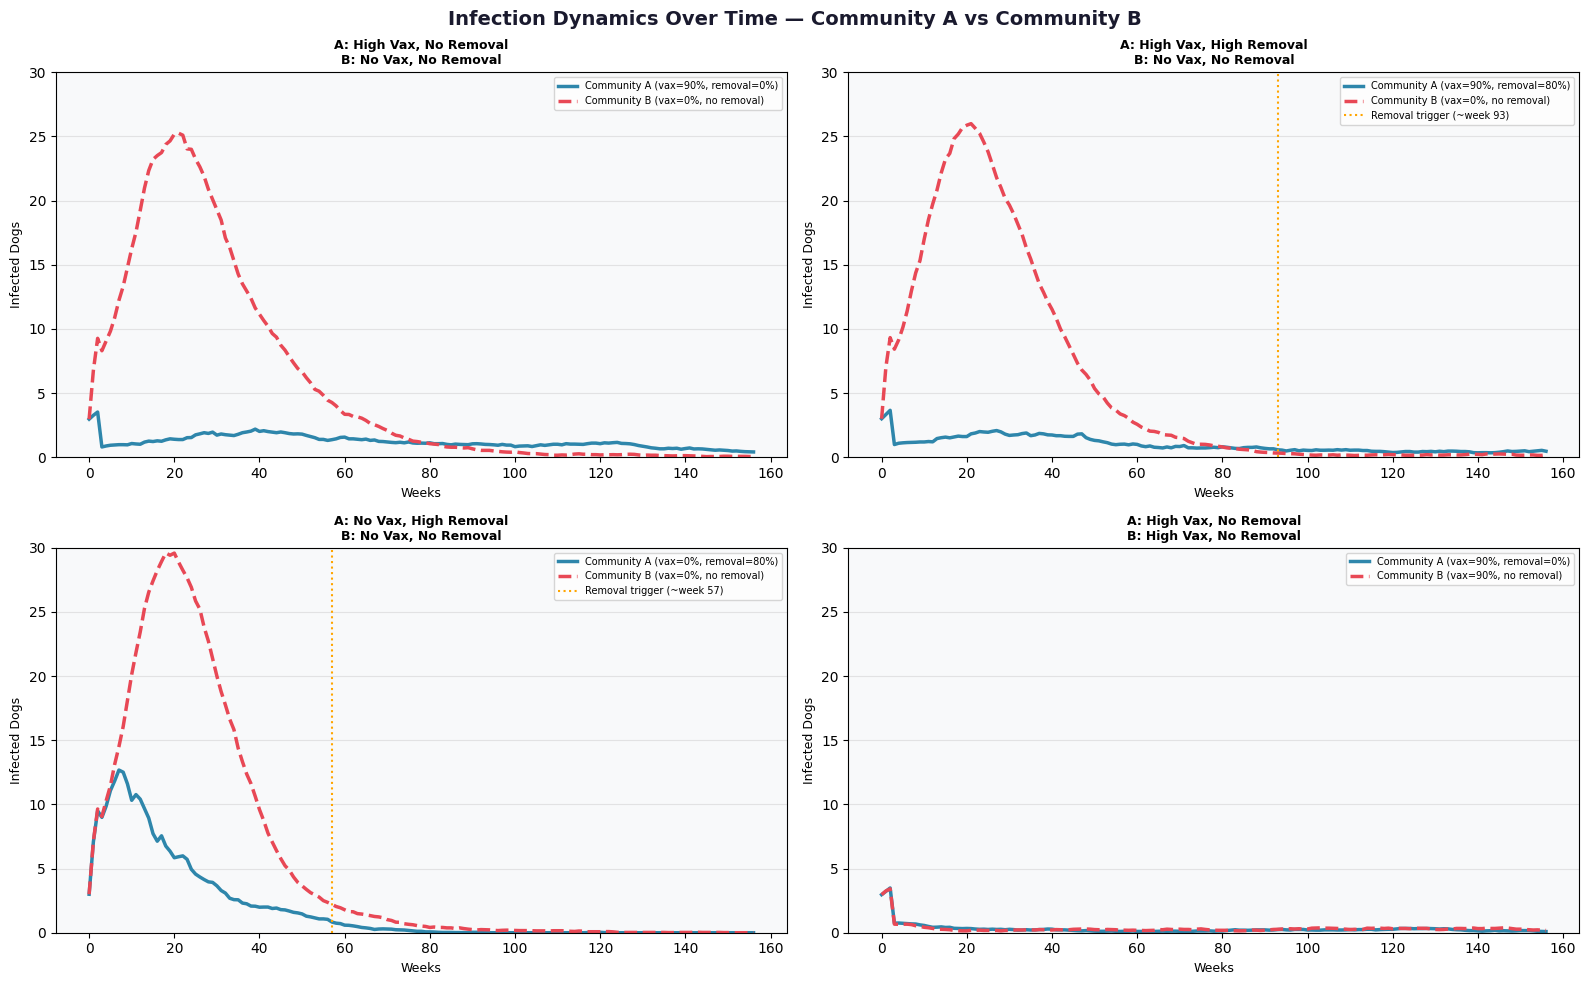

Figure 1 saved — time series


In [19]:
# FIGURE 1 — Time series: infected-A and infected-B over time For key scenarios


scenarios = [
    # (vax-A, vax-B, removal, title)
    (90, 0,  0,  'A: High Vax, No Removal\nB: No Vax, No Removal'),
    (90, 0,  80, 'A: High Vax, High Removal\nB: No Vax, No Removal'),
    (0,  0,  80, 'A: No Vax, High Removal\nB: No Vax, No Removal'),
    (90, 90, 0,  'A: High Vax, No Removal\nB: High Vax, No Removal'),
]

fig1, axes = plt.subplots(2, 2, figsize=(16, 10), facecolor='white')
fig1.suptitle('Infection Dynamics Over Time — Community A vs Community B',
              fontsize=14, fontweight='bold', color=C_DARK)

for ax, (va, vb, rm, title) in zip(axes.flatten(), scenarios):
    ax.set_ylim(0, 30)
    subset = df[
        (df[VAX_A] == va) &
        (df[VAX_B] == vb) &
        (df[REMOVAL] == rm)
    ]

    if len(subset) == 0:
        ax.set_title(f'No data: vax-A={va}, vax-B={vb}, removal={rm}')
        continue

    avg = subset.groupby(STEP)[
        ['infected-A', 'infected-B', 'population-A', 'population-B']
    ].mean()

    ax.plot(avg.index, avg['infected-A'], color=C_A, linewidth=2.5,
            label=f'Community A (vax={va}%, removal={rm}%)')
    ax.plot(avg.index, avg['infected-B'], color=C_B, linewidth=2.5,
            linestyle='--', label=f'Community B (vax={vb}%, no removal)')

    # Mark removal trigger if applicable
    if rm > 0:
        # Find approximate trigger tick
        triggered_ticks = subset[subset['total-removed'] > 0].groupby(STEP).size()
        if len(triggered_ticks) > 0:
            trigger_tick = triggered_ticks.idxmax()
            ax.axvline(trigger_tick, color='orange', linestyle=':',
                      linewidth=1.5, label=f'Removal trigger (~week {trigger_tick})')

    ax.set_title(title, fontsize=9, fontweight='bold')
    ax.set_xlabel('Weeks', fontsize=9)
    ax.set_ylabel('Infected Dogs', fontsize=9)
    ax.set_facecolor(C_BG)
    ax.legend(fontsize=7)
    ax.grid(axis='y', alpha=0.3)

plt.tight_layout()
plt.savefig('fig_phase2_timeseries.png', dpi=150, bbox_inches='tight')
plt.show()
print("Figure 1 saved — time series")


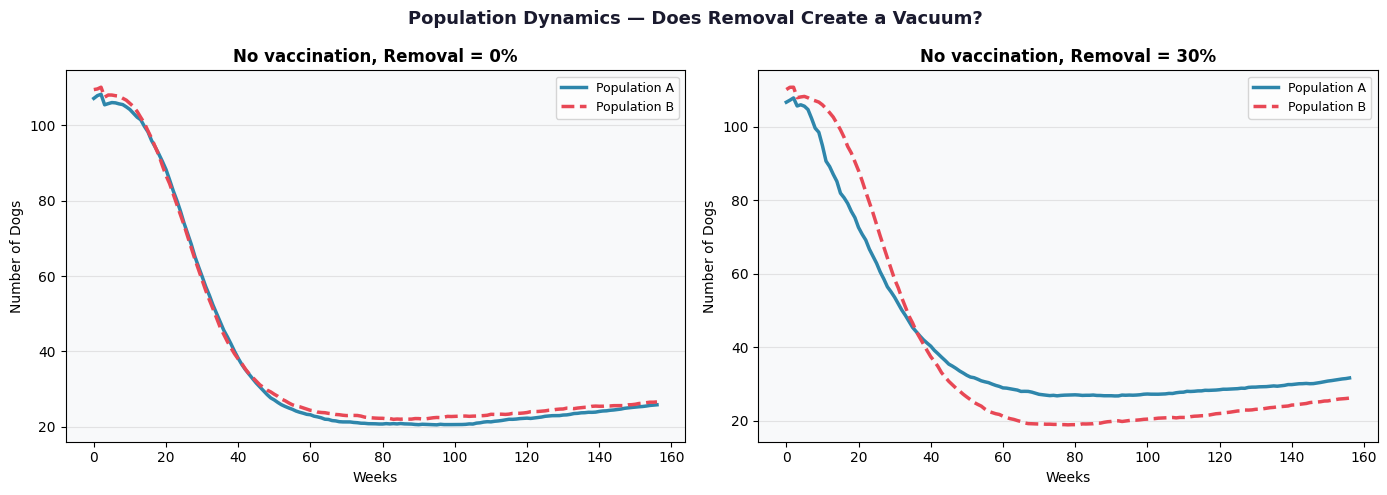

Figure 2 saved — population dynamics


In [24]:
# FIGURE 2 — Population dynamics over time
# Does removal in A create a vacuum filled by B dogs?

fig2, axes2 = plt.subplots(1, 2, figsize=(14, 5), facecolor='white')
fig2.suptitle('Population Dynamics — Does Removal Create a Vacuum?',
              fontsize=13, fontweight='bold', color=C_DARK)

# Scenario: A removes aggressively, B has no removal
for rm, ax in zip([0, 30], axes2):
    subset = df[
        (df[VAX_A] == 0) &
        (df[VAX_B] == 0) &
        (df[REMOVAL] == rm)
    ]

    if len(subset) == 0:
        continue

    avg = subset.groupby(STEP)[
        ['population-A', 'population-B']
    ].mean()

    ax.plot(avg.index, avg['population-A'], color=C_A, linewidth=2.5,
            label='Population A')
    ax.plot(avg.index, avg['population-B'], color=C_B, linewidth=2.5,
            linestyle='--', label='Population B')
    ax.set_title(f'No vaccination, Removal = {rm}%', fontweight='bold')
    ax.set_xlabel('Weeks', fontsize=10)
    ax.set_ylabel('Number of Dogs', fontsize=10)
    ax.set_facecolor(C_BG)
    ax.legend(fontsize=9)
    ax.grid(axis='y', alpha=0.3)

plt.tight_layout()
plt.savefig('fig_phase2_population_dynamics.png', dpi=150, bbox_inches='tight')
plt.show()
print("Figure 2 saved — population dynamics")

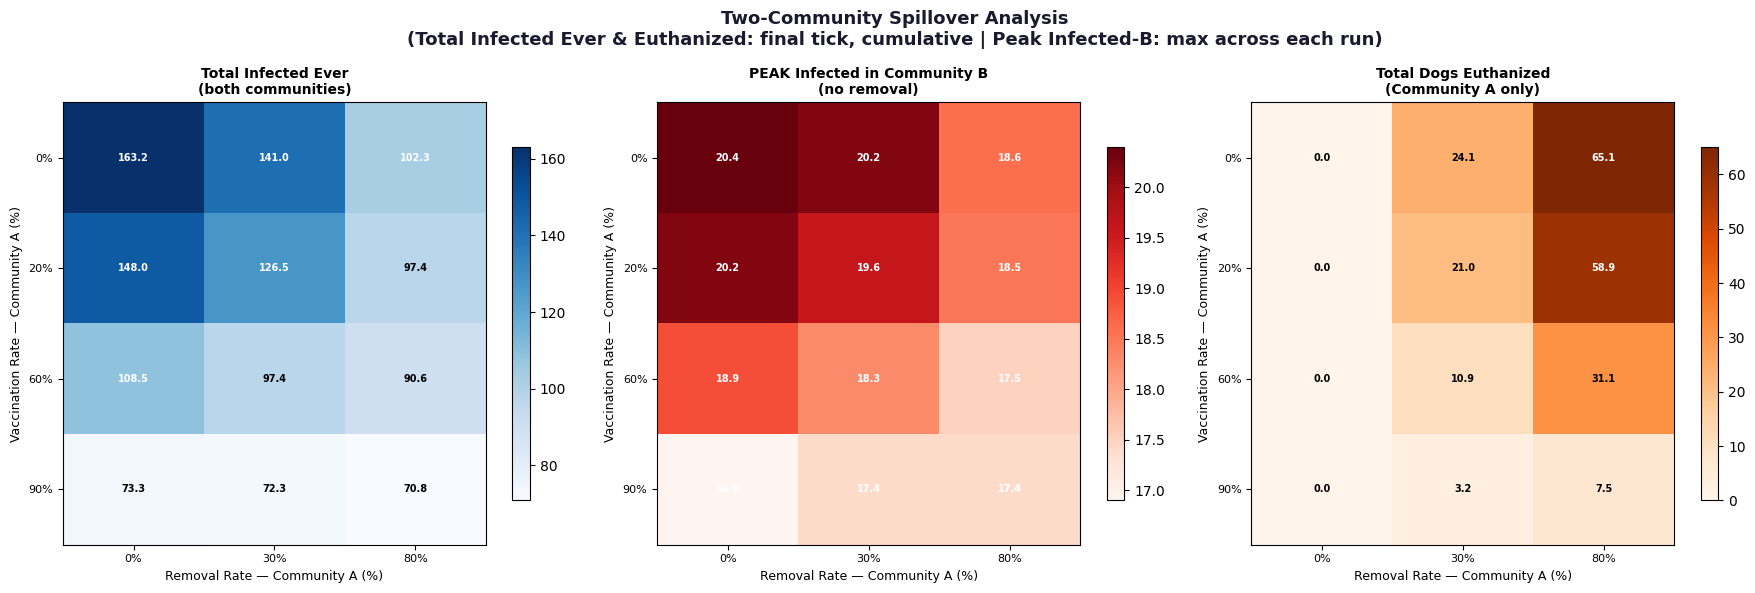

Figure 3 saved — heatmaps


In [25]:
# FIGURE 3 — Heatmaps: spillover effect

fig3, axes3 = plt.subplots(1, 3, figsize=(18, 6), facecolor='white')
fig3.suptitle('Two-Community Spillover Analysis\n(Total Infected Ever & Euthanized: final tick, cumulative | Peak Infected-B: max across each run)',
              fontsize=13, fontweight='bold', color=C_DARK)

# ---- Precompute peak infected-B per combo (across the whole run, not just final tick) ----
peak_B = df.groupby([VAX_A, REMOVAL, '[run number]'])['infected-B'].max().reset_index()
peak_B_avg = peak_B.groupby([VAX_A, REMOVAL])['infected-B'].mean().reset_index()

heatmaps = [
    ('total-infected-ever', 'Total Infected Ever\n(both communities)',   'Blues',  final),
    ('infected-B',          'PEAK Infected in Community B\n(no removal)', 'Reds',   peak_B_avg),
    ('total-died',          'Total Dogs Euthanized\n(Community A only)', 'Oranges', final),
]

for ax, (col, title, cmap, source_df) in zip(axes3, heatmaps):
    try:
        pivot = source_df.groupby([VAX_A, REMOVAL])[col].mean().unstack().round(1)
        im = ax.imshow(pivot.values, cmap=cmap, aspect='auto')
        ax.set_xticks(range(len(pivot.columns)))
        ax.set_xticklabels([f'{c}%' for c in pivot.columns], fontsize=8)
        ax.set_yticks(range(len(pivot.index)))
        ax.set_yticklabels([f'{r}%' for r in pivot.index], fontsize=8)
        ax.set_xlabel('Removal Rate — Community A (%)', fontsize=9)
        ax.set_ylabel('Vaccination Rate — Community A (%)', fontsize=9)
        ax.set_title(title, fontsize=10, fontweight='bold')
        plt.colorbar(im, ax=ax, shrink=0.8)
        for i in range(len(pivot.index)):
            for j in range(len(pivot.columns)):
                val = pivot.values[i, j]
                ax.text(j, i, f'{val:.1f}',
                        ha='center', va='center',
                        fontsize=7, fontweight='bold', color='white'
                        if val > pivot.values.max() * 0.6 else 'black')
    except Exception as e:
        ax.set_title(f'Error: {e}')

plt.tight_layout()
plt.savefig('fig_phase2_heatmaps.png', dpi=150, bbox_inches='tight')
plt.show()
print("Figure 3 saved — heatmaps")

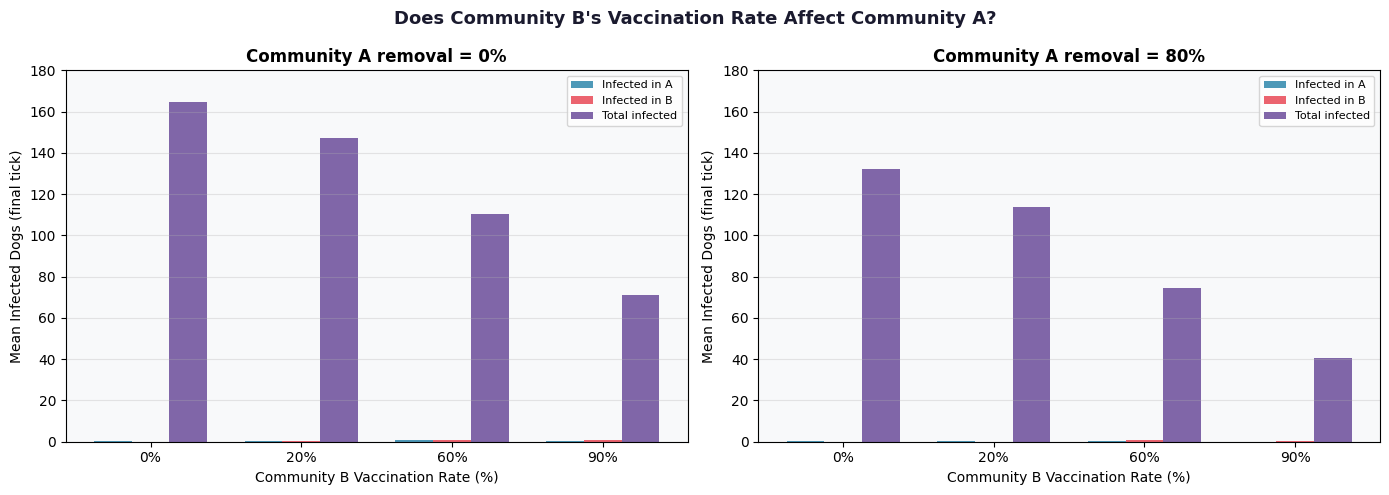

Figure 4 saved — B's effect on A


In [20]:
# FIGURE 4 — Does B's vaccination protect A?

fig4, axes4 = plt.subplots(1, 2, figsize=(14, 5), facecolor='white')
fig4.suptitle("Does Community B's Vaccination Rate Affect Community A?",
              fontsize=13, fontweight='bold', color=C_DARK)

for ax, rm in zip(axes4, [0, 80]):
    ax.set_ylim(0, 180)
    subset_final = final[final[REMOVAL] == rm]
    data = subset_final.groupby(VAX_B)[
        ['infected-A', 'infected-B', 'total-infected-ever']
    ].mean().round(1)

    x = range(len(data.index))
    width = 0.25
    ax.bar([i - width for i in x], data['infected-A'],
           width=width, color=C_A, alpha=0.85, label='Infected in A')
    ax.bar([i for i in x], data['infected-B'],
           width=width, color=C_B, alpha=0.85, label='Infected in B')
    ax.bar([i + width for i in x], data['total-infected-ever'],
           width=width, color='#6B4C9A', alpha=0.85, label='Total infected')

    ax.set_xticks(list(x))
    ax.set_xticklabels([f'{v}%' for v in data.index])
    ax.set_xlabel("Community B Vaccination Rate (%)", fontsize=10)
    ax.set_ylabel("Mean Infected Dogs (final tick)", fontsize=10)
    ax.set_title(f'Community A removal = {rm}%', fontweight='bold')
    ax.set_facecolor(C_BG)
    ax.legend(fontsize=8)
    ax.grid(axis='y', alpha=0.3)

plt.tight_layout()
plt.savefig('fig_phase2_B_effect_on_A.png', dpi=150, bbox_inches='tight')
plt.show()
print("Figure 4 saved — B's effect on A")


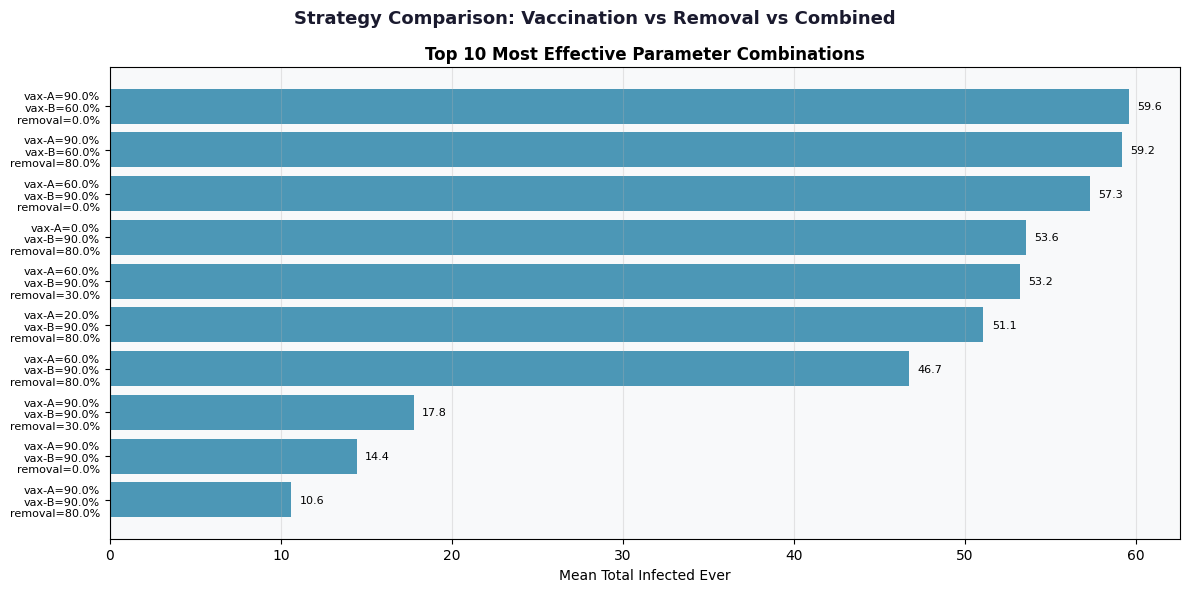

Figure 5 saved — strategy comparison

=== ALL PHASE 2 FIGURES SAVED ===
fig_phase2_timeseries.png       — infection curves over time
fig_phase2_population_dynamics.png — vacuum effect check
fig_phase2_heatmaps.png         — spillover heatmaps
fig_phase2_B_effect_on_A.png    — does B's vaccination protect A?
fig_phase2_strategy_comparison.png — best parameter combinations


In [21]:
# FIGURE 5 — The key comparison:
# Best A-only strategy vs best combined strategy

fig5, ax5 = plt.subplots(figsize=(12, 6), facecolor='white')
fig5.suptitle('Strategy Comparison: Vaccination vs Removal vs Combined',
              fontsize=13, fontweight='bold', color=C_DARK)

strategies = final.groupby([VAX_A, VAX_B, REMOVAL])[
    'total-infected-ever'
].mean().reset_index()
strategies.columns = ['vax_A', 'vax_B', 'removal', 'mean_infected']
strategies = strategies.sort_values('mean_infected')

top10 = strategies.head(10)
labels = [f"vax-A={r['vax_A']}%\nvax-B={r['vax_B']}%\nremoval={r['removal']}%"
          for _, r in top10.iterrows()]

bars = ax5.barh(range(len(top10)), top10['mean_infected'],
                color=C_A, alpha=0.85)
ax5.set_yticks(range(len(top10)))
ax5.set_yticklabels(labels, fontsize=8)
ax5.set_xlabel('Mean Total Infected Ever', fontsize=10)
ax5.set_title('Top 10 Most Effective Parameter Combinations', fontweight='bold')
ax5.set_facecolor(C_BG)
ax5.grid(axis='x', alpha=0.3)

for bar, val in zip(bars, top10['mean_infected']):
    ax5.text(bar.get_width() + 0.5, bar.get_y() + bar.get_height()/2,
             f'{val:.1f}', va='center', fontsize=8)

plt.tight_layout()
plt.savefig('fig_phase2_strategy_comparison.png', dpi=150, bbox_inches='tight')
plt.show()
print("Figure 5 saved — strategy comparison")

print("\n=== ALL PHASE 2 FIGURES SAVED ===")
print("fig_phase2_timeseries.png       — infection curves over time")
print("fig_phase2_population_dynamics.png — vacuum effect check")
print("fig_phase2_heatmaps.png         — spillover heatmaps")
print("fig_phase2_B_effect_on_A.png    — does B's vaccination protect A?")
print("fig_phase2_strategy_comparison.png — best parameter combinations")